In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [7]:
df_inv = pd.read_csv('/Users/sonam/Documents/projects/dea/vending-analysis-project/Inventory_Turnover.csv')
print('Inventory data ----------------')
print(df_inv.head())

df_re = pd.read_csv('/Users/sonam/Documents/projects/dea/vending-analysis-project/Restock_data.csv')
print('Restock data ----------------')
print(df_re.head())

Inventory data ----------------
                                sku dispense_date  \
0  05d98e5c2603bf927952aa3eb74d1fc3    22-02-2024   
1  05d98e5c2603bf927952aa3eb74d1fc3    21-02-2024   
2  05d98e5c2603bf927952aa3eb74d1fc3    20-02-2024   
3  05d98e5c2603bf927952aa3eb74d1fc3    19-02-2024   
4  05d98e5c2603bf927952aa3eb74d1fc3    18-02-2024   

                                 device_id  package_qty  qty_dispensed  
0  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20  
1  device_0749c361d8ac7047c2f98fbcb2eadd16            1              9  
2  device_0749c361d8ac7047c2f98fbcb2eadd16            1             15  
3  device_0749c361d8ac7047c2f98fbcb2eadd16            1             13  
4  device_0749c361d8ac7047c2f98fbcb2eadd16            1             24  
Restock data ----------------
                                 device_id                   global_order_id  \
0  device_0749c361d8ac7047c2f98fbcb2eadd16  05f46e618fbb92810f9eed53e2f55a73   
1  device_65ae7ea424c

In [8]:
df_inv['dispense_date'] = pd.to_datetime(df_inv['dispense_date'], format='%d-%m-%Y', errors='coerce')
df_inv.index = df_inv['dispense_date']
del df_inv['dispense_date']
print(df_inv.head())

                                            sku  \
dispense_date                                     
2024-02-22     05d98e5c2603bf927952aa3eb74d1fc3   
2024-02-21     05d98e5c2603bf927952aa3eb74d1fc3   
2024-02-20     05d98e5c2603bf927952aa3eb74d1fc3   
2024-02-19     05d98e5c2603bf927952aa3eb74d1fc3   
2024-02-18     05d98e5c2603bf927952aa3eb74d1fc3   

                                             device_id  package_qty  \
dispense_date                                                         
2024-02-22     device_0749c361d8ac7047c2f98fbcb2eadd16            1   
2024-02-21     device_0749c361d8ac7047c2f98fbcb2eadd16            1   
2024-02-20     device_0749c361d8ac7047c2f98fbcb2eadd16            1   
2024-02-19     device_0749c361d8ac7047c2f98fbcb2eadd16            1   
2024-02-18     device_0749c361d8ac7047c2f98fbcb2eadd16            1   

               qty_dispensed  
dispense_date                 
2024-02-22                20  
2024-02-21                 9  
2024-02-20          

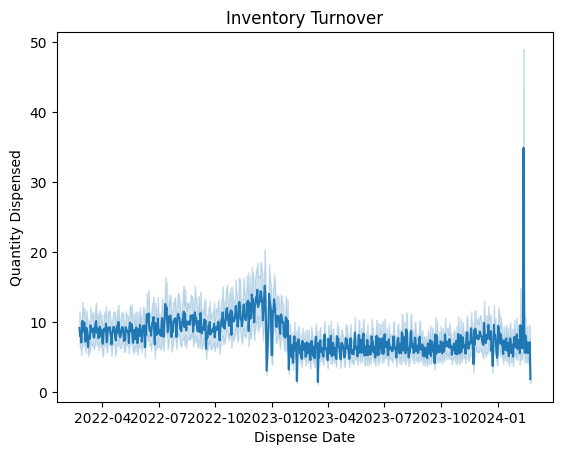

In [9]:
sns.lineplot(x=df_inv.index, y=df_inv['qty_dispensed'], data=df_inv)

plt.xlabel('Dispense Date')
plt.ylabel('Quantity Dispensed')
plt.title('Inventory Turnover')
plt.show()

In [42]:
# Merge df_inv and df_re on 'device_id'
merged_df = pd.merge(df_inv.reset_index(), df_re, on='device_id', how='left')
print('Merged DataFrame::::::::::::::::')
print(merged_df.head())

Merged DataFrame::::::::::::::::
  dispense_date                               sku  \
0    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
1    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
2    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
3    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
4    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   

                                 device_id  package_qty  qty_dispensed  \
0  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   
1  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   
2  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   
3  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   
4  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   

                    global_order_id                restock_date currency_code  \
0  05f46e618fbb92810f9eed53e2f55a73  2023-12-04 18:09:57.986537           USD   
1  08dd5a4c6a1d406a3d7f5f2c9f63e752  2024

In [43]:

# Convert date columns to datetime objects
merged_df['restock_date'] = pd.to_datetime(merged_df['restock_date'], format='%Y-%m-%d %H:%M:%S.%f',dayfirst=True)
merged_df['dispense_date'] = pd.to_datetime(merged_df['dispense_date'])

display(merged_df.head())

,dispense_date,sku,device_id,package_qty,qty_dispensed,global_order_id,restock_date,currency_code,total
0,2024-02-22,05d98e5c2603bf927952aa3eb74d1fc3,device_0749c361d8ac7047c2f98fbcb2eadd16,1,20,05f46e618fbb92810f9eed53e2f55a73,2023-12-04 18:09:57.986537,USD,359.58
1,2024-02-22,05d98e5c2603bf927952aa3eb74d1fc3,device_0749c361d8ac7047c2f98fbcb2eadd16,1,20,08dd5a4c6a1d406a3d7f5f2c9f63e752,2024-01-24 15:04:48.844780,USD,43.08
2,2024-02-22,05d98e5c2603bf927952aa3eb74d1fc3,device_0749c361d8ac7047c2f98fbcb2eadd16,1,20,9bfc4033193d4556360b4729fe25e75c,2023-06-30 14:29:48.834370,USD,177.15
3,2024-02-22,05d98e5c2603bf927952aa3eb74d1fc3,device_0749c361d8ac7047c2f98fbcb2eadd16,1,20,3a56d92d6647c97a7ef30794508d5df3,2024-01-19 20:09:38.839399,USD,292.40
4,2024-02-22,05d98e5c2603bf927952aa3eb74d1fc3,device_0749c361d8ac7047c2f98fbcb2eadd16,1,20,c4ecd97cdc5138c91bcb1a3769dd0bd5,2024-02-07 15:19:56.368352,USD,66.96


In [32]:
# Sort by date to ensure the timeline is chronological
merged_df = merged_df.sort_values(by='dispense_date')
display(merged_df.head())

,dispense_date,sku,device_id,package_qty,qty_dispensed,global_order_id,restock_date,currency_code,total
4445857,2022-02-23,0300087aca6bca74aea4cfa71bbb5adb,device_c287be7e02167387bf9e7eca061ce5b5,1,6,23f3918af075b5366410a1cf95298ef0,2023-11-13 14:44:33.096998,USD,304.17
3991563,2022-02-23,9a154810b166b91ae0c3d0cd84fb7e05,device_af645ebf4c96eb6e430529a2a9913686,1,15,864b0acf83ac9fdf54d31fdcb5874956,2023-07-28 14:49:49.786576,USD,176.68
629380,2022-02-23,be61be55295db1941eaf232ee6288fa7,device_0749c361d8ac7047c2f98fbcb2eadd16,1,34,0c81fcaef86e6f558405891539f81811,2023-08-07 15:49:43.652740,USD,293.32
629391,2022-02-23,be61be55295db1941eaf232ee6288fa7,device_0749c361d8ac7047c2f98fbcb2eadd16,1,34,6a6383475a4c65f57f00aee9a5b30397,2023-07-05 16:34:37.232805,USD,126.73
629381,2022-02-23,be61be55295db1941eaf232ee6288fa7,device_0749c361d8ac7047c2f98fbcb2eadd16,1,34,cb0d12dd972b74584224b5ecd89b1d64,2023-09-25 14:49:38.694578,USD,231.91


In [65]:
# Add day of week column based on dispense_date
merged_df['dispense_day_ofweek'] = merged_df['dispense_date'].dt.day_name()
print("Added 'dispense_day_ofweek' column:")
print(merged_df.head(10))

Added 'dispense_day_ofweek' column:
  dispense_date                               sku  \
0    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
1    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
2    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
3    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
4    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
5    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
6    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
7    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
8    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   
9    2024-02-22  05d98e5c2603bf927952aa3eb74d1fc3   

                                 device_id  package_qty  qty_dispensed  \
0  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   
1  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   
2  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   
3  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20   
4  device_

In [37]:
# 1. Check for missing values
print("Missing values in Inventory:\n", merged_df.isnull().sum())

# 2. Remove duplicates
merged_df = merged_df.drop_duplicates()


Missing values in Inventory:
 dispense_date      0
sku                0
device_id          0
package_qty        0
qty_dispensed      0
global_order_id    0
restock_date       0
currency_code      0
total              0
dtype: int64


In [36]:

print(f"Cleaned Inventory Shape: {merged_df.shape}")

Cleaned Inventory Shape: (5652348, 9)


In [40]:
# Grouping by Date and SKU to get daily totals
daily_inventory = merged_df.groupby(['dispense_date', 'sku']).agg({
    'qty_dispensed': 'sum',
    'device_id': 'first' # Keep track of which machine it was in
}).reset_index()

display(daily_inventory.head(20))


,dispense_date,sku,qty_dispensed,device_id
0,2022-02-23,0294e9ff7bc77c29cdd83b6125ee4940,710,device_65ae7ea424c57d46ac409256fe359349
1,2022-02-23,0300087aca6bca74aea4cfa71bbb5adb,906,device_c287be7e02167387bf9e7eca061ce5b5
2,2022-02-23,05d98e5c2603bf927952aa3eb74d1fc3,2363,device_0749c361d8ac7047c2f98fbcb2eadd16
3,2022-02-23,099cc517501503ede4c1646885d437d7,444,device_af645ebf4c96eb6e430529a2a9913686
4,2022-02-23,13f6ca567dde83523d4c883c16b98148,453,device_c287be7e02167387bf9e7eca061ce5b5
5,2022-02-23,16eff917bdf1fbe64883aa4bb8b4a1f8,592,device_af645ebf4c96eb6e430529a2a9913686
6,2022-02-23,1987e6b98c8edc352a961cc293ffe981,1661,device_c287be7e02167387bf9e7eca061ce5b5
7,2022-02-23,1b28e970471a105335f8c9d673940d58,284,device_65ae7ea424c57d46ac409256fe359349
8,2022-02-23,1fc36e6327e578011358e52fcedfda9a,426,device_6726f2a054f54836aaabe8c7643286bc
9,2022-02-23,2ecc882f649bf4ea25cf8a1a6eb77b6e,1812,device_c287be7e02167387bf9e7eca061ce5b5


In [41]:
# Summary stats for numerical columns
print(merged_df[['qty_dispensed']].describe())

# Check how many unique SKUs and Devices you are managing
print(f"Total Unique SKUs: {merged_df['sku'].nunique()}")
print(f"Total Devices: {merged_df['device_id'].nunique()}")

       qty_dispensed
count   5.652348e+06
mean    8.106246e+00
std     9.006615e+00
min     1.000000e+00
25%     2.000000e+00
50%     5.000000e+00
75%     1.100000e+01
max     1.620000e+02
Total Unique SKUs: 82
Total Devices: 5


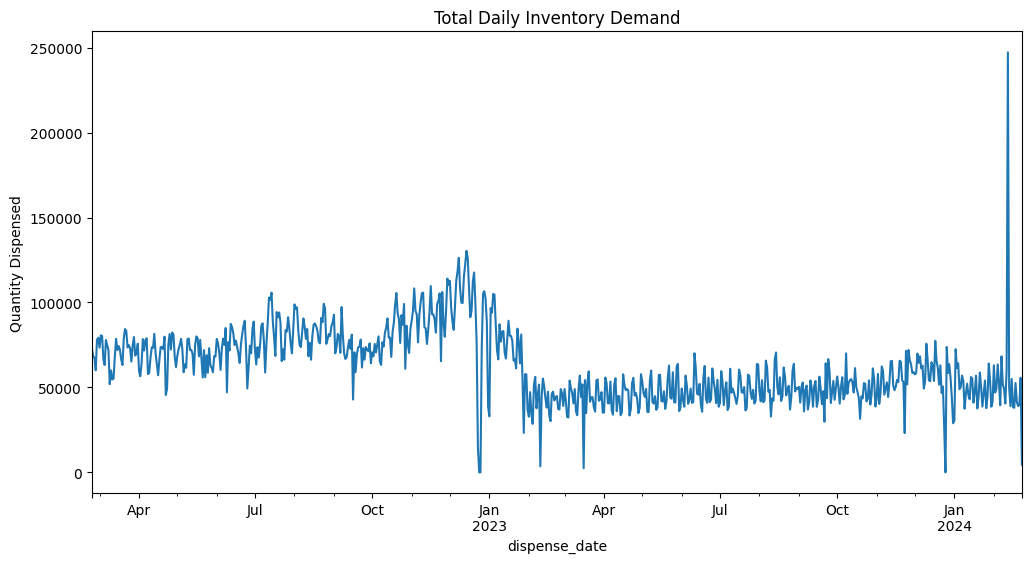

In [67]:
# Resample to daily demand for the whole inventory
daily_total = merged_df.set_index('dispense_date')['qty_dispensed'].resample('D').sum()


plt.figure(figsize=(12, 6))
daily_total.plot(title='Total Daily Inventory Demand')
plt.ylabel('Quantity Dispensed')
plt.show()

In [68]:
# Resample to Day of the week demand for the whole inventory
dayofweek_total = merged_df.groupby('dispense_day_ofweek')['qty_dispensed'].sum().sort_values(ascending=False)


plt.figure(figsize=(12, 6))
dayofweek_total.plot(title='Total Inventory Demand on Days of the Week', kind='bar')
plt.ylabel('Quantity Dispensed')
plt.show()

AttributeError: 'numpy.int64' object has no attribute 'plot'

<Figure size 1200x600 with 0 Axes>

In [48]:
# Group by SKU and sum the quantities dispensed, then sort in descending order
sku_summary = daily_inventory.groupby('sku')['qty_dispensed'].sum().sort_values(ascending=False).head(10)

# Display top 10 SKUs
print("Top 10 SKUs by Total Quantity Dispensed:")
print(sku_summary)

Top 10 SKUs by Total Quantity Dispensed:
sku
b1cfc8c80d03027941b0bce8d2ff3deb    3101990
be61be55295db1941eaf232ee6288fa7    2400947
9a154810b166b91ae0c3d0cd84fb7e05    2380284
93d664dddeea2dd49decf97035051e92    2328090
da3562c59621dd135d3f0255d3fb66aa    2217133
ff9575eadeeb732ad8095286dc2bff82    1830213
690b7d2f4218991b6496be8eb456a943    1821718
b701576d3b2e8ea055ac68016e01668e    1747594
05d98e5c2603bf927952aa3eb74d1fc3    1675228
78baaaf1b752a5358cb6835cf1a7ef8d    1539564
Name: qty_dispensed, dtype: int64


/var/folders/f_/9nd0d7f906xd_4gzp2lf2h5h0000gn/T/ipykernel_37697/1150972498.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=sku_summary.index, x=sku_summary.values, palette='viridis')


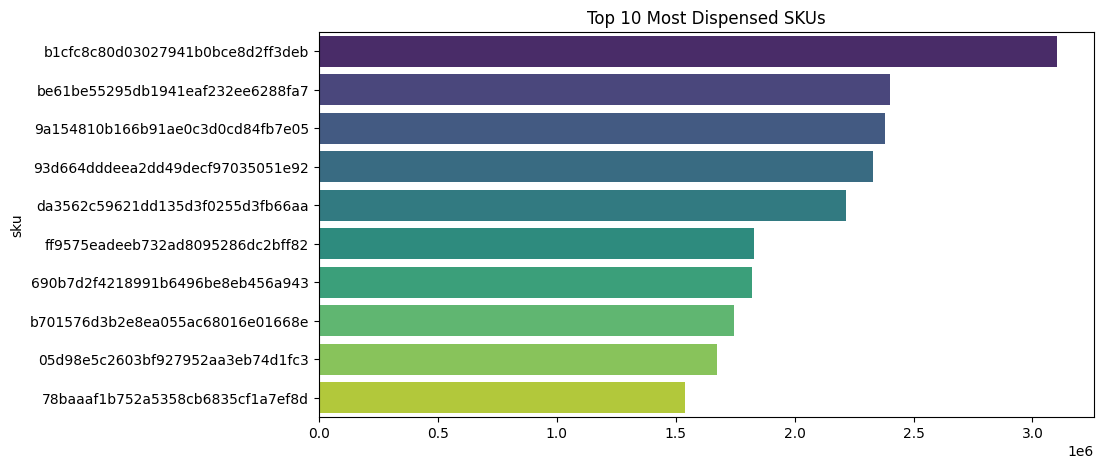

In [50]:
plt.figure(figsize=(10, 5))
sns.barplot(y=sku_summary.index, x=sku_summary.values, palette='viridis')
plt.title('Top 10 Most Dispensed SKUs')
plt.xticks(rotation=0)
plt.show()

In [51]:
# Calculate Coefficient of Variation (CV = Std Dev / Mean)
sku_stats = merged_df.groupby('sku')['qty_dispensed'].agg(['mean', 'std'])
sku_stats['CV'] = sku_stats['std'] / sku_stats['mean']

# High CV (> 1.0) means very unpredictable demand
unpredictable_items = sku_stats.sort_values(by='CV', ascending=False).head(5)
print("Most Unpredictable SKUs:\n", unpredictable_items)

Most Unpredictable SKUs:
                                       mean       std        CV
sku                                                           
1fc36e6327e578011358e52fcedfda9a  3.169312  2.807712  0.885906
9d60025d39c34f6d75a0110e3957b79b  1.617391  1.367888  0.845737
d8f674f1baeb28ba583c9c467e67365d  2.911392  2.454173  0.842955
01bdf04bb36dfcd94a9ef6fce31afc59  1.766537  1.290498  0.730524
912562560d2e2e4558eed7feaaf1cba1  3.626230  2.632965  0.726089


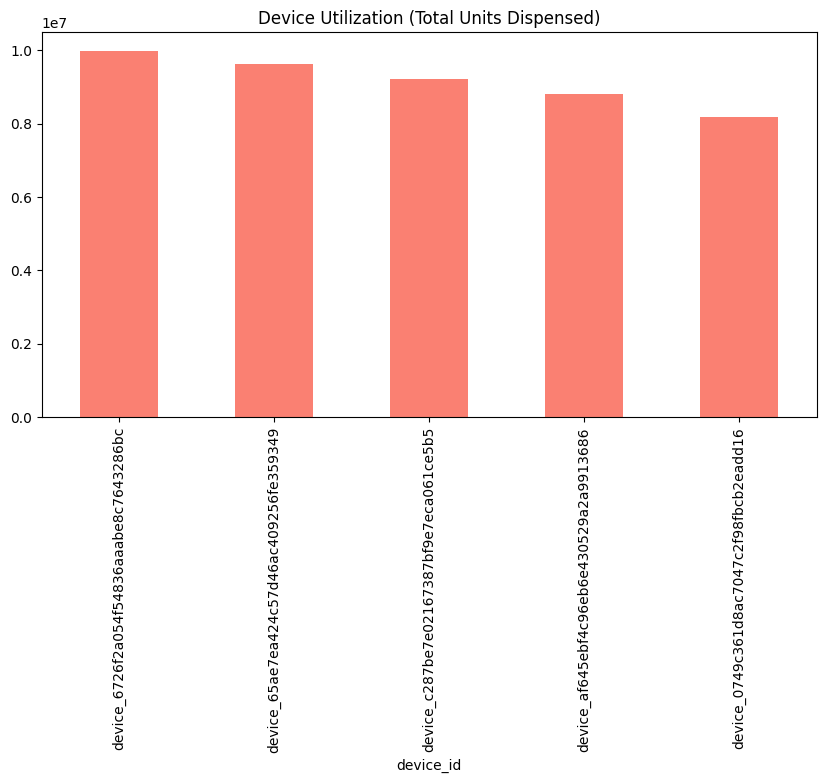

In [57]:
# Average daily dispenses per device
device_usage = merged_df.groupby('device_id')['qty_dispensed'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
device_usage.plot(kind='bar', color='salmon')
plt.title('Device Utilization (Total Units Dispensed)')
plt.show()

In [ ]:
# Find top SKU ID based on max quantity dispensed
top_sku = merged_df.groupby('sku')['qty_dispensed'].sum().idxmax()
top_sku_total = merged_df.groupby('sku')['qty_dispensed'].sum().max()

print(f"Top SKU ID: {top_sku}")
print(f"Total Quantity Dispensed: {top_sku_total}")
print("\nTop 10 SKUs by total quantity dispensed:")
print(merged_df.groupby('sku')['qty_dispensed'].sum().nlargest(10))

Top SKU ID: b1cfc8c80d03027941b0bce8d2ff3deb
Total Quantity Dispensed: 3101990

Top 10 SKUs by total quantity dispensed:
sku
b1cfc8c80d03027941b0bce8d2ff3deb    3101990
be61be55295db1941eaf232ee6288fa7    2400947
9a154810b166b91ae0c3d0cd84fb7e05    2380284
93d664dddeea2dd49decf97035051e92    2328090
da3562c59621dd135d3f0255d3fb66aa    2217133
ff9575eadeeb732ad8095286dc2bff82    1830213
690b7d2f4218991b6496be8eb456a943    1821718
b701576d3b2e8ea055ac68016e01668e    1747594
05d98e5c2603bf927952aa3eb74d1fc3    1675228
78baaaf1b752a5358cb6835cf1a7ef8d    1539564
Name: qty_dispensed, dtype: int64


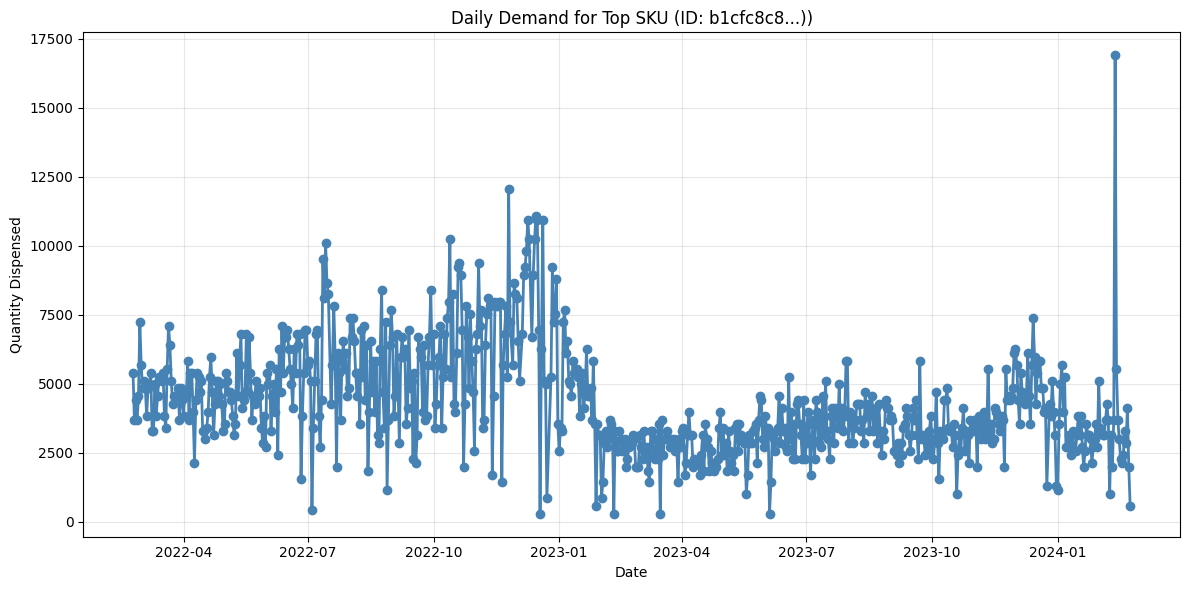

In [79]:
# Plot daily demand for top SKU
## top_sku = merged_df.groupby('sku')['qty_dispensed'].sum().idxmax()
top_sku_data = merged_df[merged_df['sku'] == top_sku].copy()
daily_demand = top_sku_data.groupby('dispense_date')['qty_dispensed'].sum().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_demand.index, daily_demand.values, marker='o', linewidth=2, markersize=6, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Quantity Dispensed')
plt.title(f'Daily Demand for Top SKU (ID: {top_sku[:8]}...))')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/f_/9nd0d7f906xd_4gzp2lf2h5h0000gn/T/ipykernel_37697/1647212597.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_demand.index, y=weekday_demand.values, palette='coolwarm')


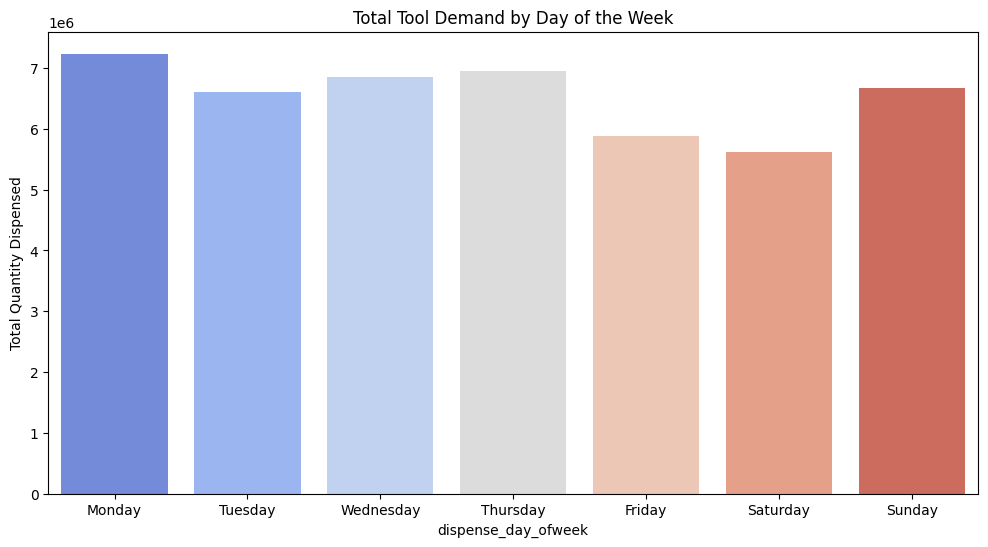

In [83]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_demand = merged_df.groupby('dispense_day_ofweek')['qty_dispensed'].sum().reindex(days_order)

plt.figure(figsize = (12,6))
sns.barplot(x=weekday_demand.index, y=weekday_demand.values, palette='coolwarm')
plt.title('Total Tool Demand by Day of the Week')
plt.ylabel('Total Quantity Dispensed')
# Prevent the width from wrapping to the next line
pd.set_option('display.expand_frame_repr', False)

# Set a very large width so it stays on one line
pd.set_option('display.width', 1000)
plt.show()

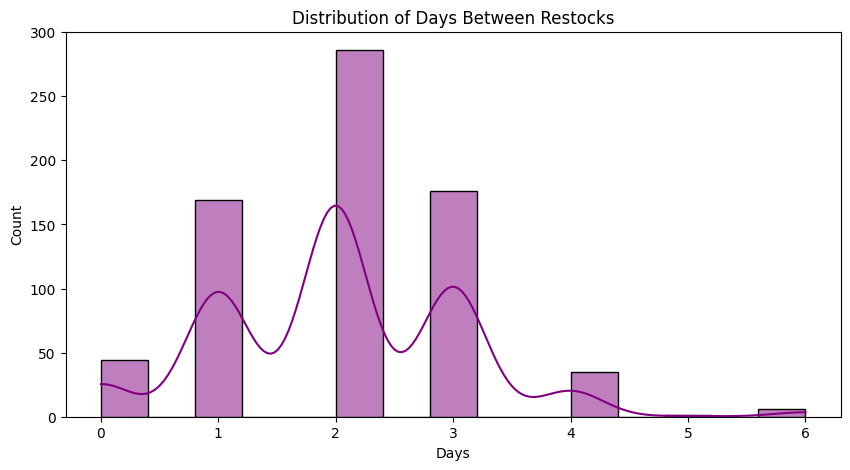

Average Restock Interval: 2.02 days


In [95]:
# Prevent the width from wrapping to the next line
pd.set_option('display.expand_frame_repr', False)

# Set a very large width so it stays on one line
pd.set_option('display.width', 1000)

df_re['restock_date'] = pd.to_datetime(df_re['restock_date'], format='%Y-%m-%d %H:%M:%S.%f',dayfirst=True)

# Sort by device and date, then calculate the gap between restocks
restock = df_re.sort_values(['device_id', 'restock_date'])
restock['days_between_restocks'] = restock.groupby('device_id')['restock_date'].diff().dt.days

plt.figure(figsize=(10, 5))
sns.histplot(restock['days_between_restocks'].dropna(), bins=15, kde=True, color='purple')
plt.title('Distribution of Days Between Restocks')
plt.xlabel('Days')
plt.show()

print(f"Average Restock Interval: {restock['days_between_restocks'].mean():.2f} days")

In [96]:
# Calculate mean, standard deviation, and Coefficient of Variation (CV)
sku_stats = merged_df.groupby('sku')['qty_dispensed'].agg(['mean', 'std']).fillna(0)
sku_stats['CV'] = sku_stats['std'] / sku_stats['mean']

# Filter for the most unpredictable items
unpredictable_skus = sku_stats.sort_values(by='CV', ascending=False).head(5)
print("Top 5 High-Variance SKUs (Critical for Safety Stock Planning):")
display(unpredictable_skus)

Top 5 High-Variance SKUs (Critical for Safety Stock Planning):


,mean,std,CV
sku,,,
1fc36e6327e578011358e52fcedfda9a,3.169312,2.807712,0.885906
9d60025d39c34f6d75a0110e3957b79b,1.617391,1.367888,0.845737
d8f674f1baeb28ba583c9c467e67365d,2.911392,2.454173,0.842955
01bdf04bb36dfcd94a9ef6fce31afc59,1.766537,1.290498,0.730524
912562560d2e2e4558eed7feaaf1cba1,3.626230,2.632965,0.726089


In [98]:
# Phase 3: Feature Engineering

# 1. Aggregate to Daily Level (SKU + Device)
df_daily = merged_df.groupby(['dispense_date', 'sku', 'device_id'])['qty_dispensed'].sum().reset_index()
df_daily = df_daily.sort_values(['sku', 'device_id', 'dispense_date'])

# 2. Add Calendar Features
df_daily['month'] = df_daily['dispense_date'].dt.month
df_daily['day_of_week'] = df_daily['dispense_date'].dt.dayofweek
df_daily['is_weekend'] = df_daily['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 3. Add Lag Features (Important: Group by SKU and Device so we don't mix products)
df_daily['lag_1'] = df_daily.groupby(['sku', 'device_id'])['qty_dispensed'].shift(1)
df_daily['lag_7'] = df_daily.groupby(['sku', 'device_id'])['qty_dispensed'].shift(7)

# 4. Add Rolling Features (7-day Average)
df_daily['rolling_mean_7'] = df_daily.groupby(['sku', 'device_id'])['qty_dispensed'].transform(lambda x: x.rolling(window=7).mean())

# 5. Clean up the resulting NaNs (from the lags)
df_model_ready = df_daily.dropna()

print("Features Generated successfully!")
display(df_model_ready.head(20))

Features Generated successfully!


,dispense_date,sku,device_id,qty_dispensed,month,day_of_week,is_weekend,lag_1,lag_7,rolling_mean_7
812,2022-03-09,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,142,3,2,0,284.0,142.0,344.857143
868,2022-03-10,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,426,3,3,0,142.0,142.0,385.428571
920,2022-03-11,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,710,3,4,0,426.0,284.0,446.285714
970,2022-03-12,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,568,3,5,1,710.0,568.0,446.285714
1020,2022-03-13,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,568,3,6,1,568.0,852.0,405.714286
1070,2022-03-14,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,142,3,0,0,568.0,142.0,405.714286
1132,2022-03-15,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,142,3,1,0,142.0,284.0,385.428571
1248,2022-03-17,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,710,3,3,0,142.0,142.0,466.571429
1303,2022-03-18,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,426,3,4,0,710.0,426.0,466.571429
1362,2022-03-19,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,710,3,5,1,426.0,710.0,466.571429


Mean Absolute Error: 481.43 units
      dispense_date                               sku                                device_id  qty_dispensed  month  day_of_week  is_weekend  lag_1  lag_7  rolling_mean_7
37529    2024-01-25  01bdf04bb36dfcd94a9ef6fce31afc59  device_65ae7ea424c57d46ac409256fe359349            284      1            3           0  142.0  142.0      162.285714
38290    2024-02-09  01bdf04bb36dfcd94a9ef6fce31afc59  device_65ae7ea424c57d46ac409256fe359349            142      2            4           0  284.0  142.0      162.285714
38438    2024-02-12  01bdf04bb36dfcd94a9ef6fce31afc59  device_65ae7ea424c57d46ac409256fe359349            426      2            0           0  142.0  142.0      202.857143
38526    2024-02-14  01bdf04bb36dfcd94a9ef6fce31afc59  device_65ae7ea424c57d46ac409256fe359349            284      2            2           0  426.0  142.0      223.142857
38714    2024-02-18  01bdf04bb36dfcd94a9ef6fce31afc59  device_65ae7ea424c57d46ac409256fe359349            

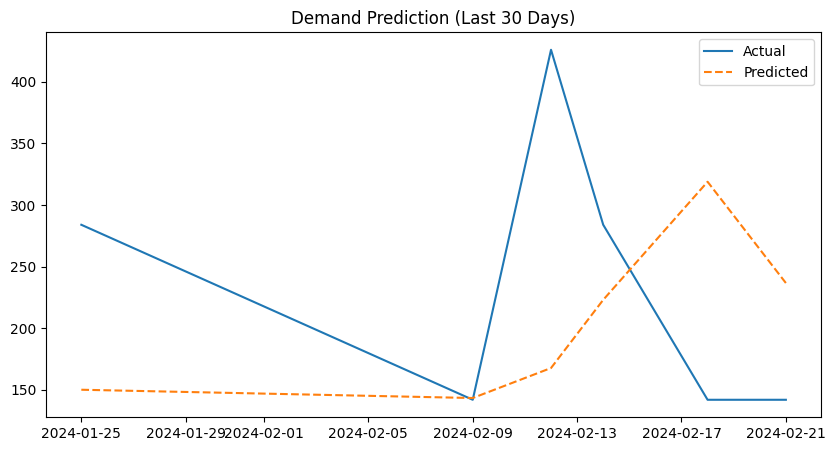

In [102]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# 1. Prepare Features & Target
# Ensure you have already run the Phase 3 code to get 'df_model_ready'
features = ['month', 'day_of_week', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']
target = 'qty_dispensed'

# 2. Chronological Split (Last 30 days for testing)
split_date = df_model_ready['dispense_date'].max() - pd.Timedelta(days=30)
train = df_model_ready[df_model_ready['dispense_date'] <= split_date]
test = df_model_ready[df_model_ready['dispense_date'] > split_date]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 3. Build & Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} units")

# 5. Visualizing for a specific SKU
# Choose one SKU and plot its actual vs predicted values
import matplotlib.pyplot as plt
sample_sku = test[test['sku'] == test['sku'].iloc[0]]
print(sample_sku)
plt.figure(figsize=(10, 5))
plt.plot(sample_sku['dispense_date'], sample_sku['qty_dispensed'], label='Actual')
plt.plot(sample_sku['dispense_date'], model.predict(sample_sku[features]), label='Predicted', linestyle='--')
plt.legend()
plt.title('Demand Prediction (Last 30 Days)')
plt.show()

In [103]:
import numpy as np

# 1. Calculate SKU-level demand statistics
daily_sku_demand = merged_df.groupby(['dispense_date', 'sku'])['qty_dispensed'].sum().reset_index()
sku_stats = daily_sku_demand.groupby('sku')['qty_dispensed'].agg(['mean', 'std']).rename(columns={
    'mean': 'avg_daily_demand',
    'std': 'std_dev_demand'
}).fillna(0)

# 2. Optimization Parameters
lead_time = 3 # Assumed 3-day lead time
service_level = 1.65 # 95% service level

# 3. Calculate Safety Stock & Reorder Point
sku_stats['safety_stock'] = np.ceil(service_level * sku_stats['std_dev_demand'] * np.sqrt(lead_time))
sku_stats['reorder_point'] = np.ceil((sku_stats['avg_daily_demand'] * lead_time) + sku_stats['safety_stock'])

# 4. Final Recommendation Table for your Report
optimization_report = sku_stats.sort_values(by='avg_daily_demand', ascending=False).head(10)
print("--- INDUSTRIAL VENDING OPTIMIZATION REPORT ---")
display(optimization_report[['avg_daily_demand', 'safety_stock', 'reorder_point']])

--- INDUSTRIAL VENDING OPTIMIZATION REPORT ---


,avg_daily_demand,safety_stock,reorder_point
sku,,,
b1cfc8c80d03027941b0bce8d2ff3deb,4290.442600,5515.0,18387.0
be61be55295db1941eaf232ee6288fa7,3469.576590,5702.0,16111.0
9a154810b166b91ae0c3d0cd84fb7e05,3283.150345,3412.0,13262.0
93d664dddeea2dd49decf97035051e92,3237.955494,4537.0,14251.0
da3562c59621dd135d3f0255d3fb66aa,3079.351389,3982.0,13221.0
ff9575eadeeb732ad8095286dc2bff82,2660.193314,3907.0,11888.0
690b7d2f4218991b6496be8eb456a943,2509.253444,3754.0,11282.0
b701576d3b2e8ea055ac68016e01668e,2427.213889,3100.0,10382.0
05d98e5c2603bf927952aa3eb74d1fc3,2313.850829,4105.0,11047.0
